<a href="https://colab.research.google.com/github/Bubukisapisa/ML_education/blob/main/HW_NLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [4]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
import matplotlib.pyplot as plt
import seaborn as sns

Mounted at /content/drive


In [5]:
from nltk.stem.snowball import SnowballStemmer
from nltk.corpus import stopwords
import nltk
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer

In [6]:
!conda install -c conda-forge xgboost
from xgboost import XGBClassifier
! pip freeze | grep xgboost

/bin/bash: line 1: conda: command not found
xgboost==3.2.0


In [7]:
df = pd.read_csv('drive/MyDrive/ML for people/tweet_sentiment_train.csv.zip')

In [8]:
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [10]:
df = df[df['text'].notna()]

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [11]:
df['sentiment'].value_counts()

,count
sentiment,
neutral,11117
positive,8582
negative,7781


In [12]:
df['text_len'] = df['text'].str.len()

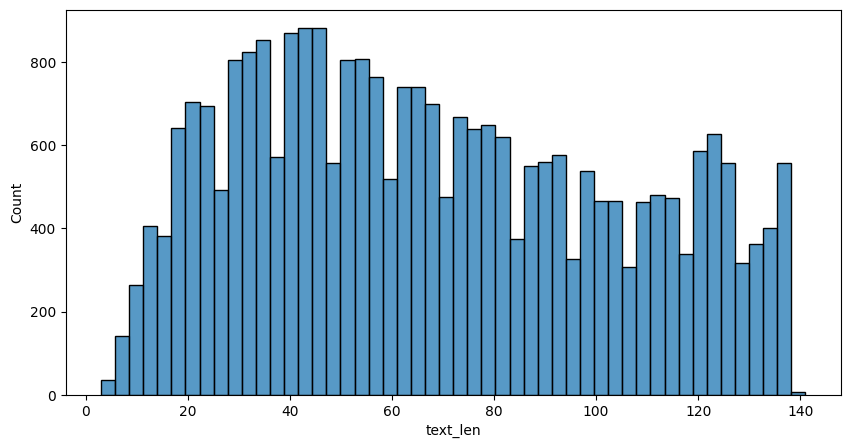

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='text_len', bins=50)
plt.show()

Розподіл таргет ознаки близький до рівномірного з невеликим скошенням до neutral значень.
Більшість постів мають приблизно від 18 до 90 символів. Також кількість постів де є 120+ символів збільшується (припущення що ці пости не нейтральні).

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [14]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [15]:
english_stopwords = stopwords.words('english')

In [16]:
stemmer = SnowballStemmer(language='english')

будуємо графік, щоб побачити з якого частотою зявляються слова

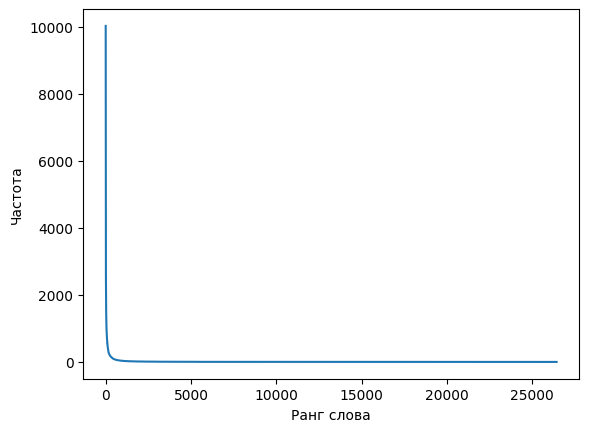

In [17]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['text'])

word_freq = X.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({'word': words, 'freq': word_freq})
freq_df = freq_df.sort_values('freq', ascending=False)

# де "обривається" крива?
plt.plot(range(len(freq_df)), freq_df['freq'])
plt.xlabel('Ранг слова')
plt.ylabel('Частота')
plt.show()

тобто десь 500-1000 слів зустрічаються найчастіше, решта - рідкісні випадки. обчислимо яка кількість слів покрикає 90% всього тексту

In [18]:
freq_df_sorted = freq_df.sort_values('freq', ascending=False)
total = freq_df_sorted['freq'].sum()
freq_df_sorted['cumulative'] = freq_df_sorted['freq'].cumsum() / total

# скільки слів потрібно для 90% покриття?
n_words_90 = (freq_df_sorted['cumulative'] <= 0.90).sum()
print(n_words_90)

4164


In [19]:
def my_preprocessor(text):
  text = text.lower()
  return text

def my_tokenizer(text):
  tokens = word_tokenize(text)
  tokens = [stemmer.stem(t) for t in tokens]
  return tokens

vectorizer = CountVectorizer(
    preprocessor=my_preprocessor,
    tokenizer=my_tokenizer,
    stop_words=list(english_stopwords),
    max_features=4000
)

In [20]:
vect_fit = vectorizer.fit(df.text)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'m", "'s", 'abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', "n't", 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


In [21]:
vectors = vectorizer.transform(df.text)

In [22]:
vectors.shape

(27480, 4000)

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



####Перевіряємо логістичну *регресію*

In [23]:
df = df.reset_index(drop=True)

In [24]:
df['target'] = df['sentiment'].map({'neutral': 0, 'positive': 1, 'negative': 2})

In [25]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42
)

X_train_bow = vectors[train_idx]
X_test_bow = vectors[test_idx]

y_train = df.loc[train_idx, 'target']
y_test = df.loc[test_idx, 'target']

In [26]:
log_reg=LogisticRegression(C=0.1, max_iter=1000, multi_class='multinomial', solver='lbfgs')

In [27]:
log_reg.fit(X_train_bow, y_train)

predict = log_reg.predict(X_test_bow)
predict_proba = log_reg.predict_proba(X_test_bow)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [28]:
predict_train = log_reg.predict(X_train_bow)
f1_score(y_train, predict_train, average=None)

array([0.74483181, 0.77515962, 0.72007842])

In [29]:
f1_score(y_test, predict, average=None)

array([0.69393512, 0.73612824, 0.63626571])

####Перевіряємо XGBclassifier

In [30]:
xgb_clf = XGBClassifier(
    max_depth=3,
    n_estimators=200,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.3,
    device='cuda'
)

xgb_clf.fit(X_train_bow, y_train)

xgb_train_pred = xgb_clf.predict(X_train_bow)
xgb_test_pred = xgb_clf.predict(X_test_bow)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:24:29] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:24:29] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


In [31]:
f1_score(y_train, xgb_train_pred, average=None)

array([0.69394883, 0.71505461, 0.60741033])

In [32]:
f1_score(y_test, xgb_test_pred, average=None)

array([0.6846473 , 0.72126984, 0.57637795])

#### Висновок
Обидві моделі показали себе краще ніж очікував (вважаю 0.6+ по кожному класу гарним результат з врахуванням того, що не проводив додатковий аналіз результату попередньої обробки - бачив коментарі інших учасників курсу, що після обробки значення по типу **** зникали, хоча очевидно що це лайка і такі слова вплинуть на результат)

Віддав би перевагу логістичній регресії, вона показує себе краще по f1 на всіх класах

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [33]:
feature_importance = pd.Series(log_reg.coef_[2], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance

,imp
sad,1.713263
suck,1.533453
miss,1.518305
hate,1.485572
sorri,1.461278
...,...
glad,-0.952401
hope,-0.970995
awesom,-1.217950
thank,-1.321484


Виглядає абсолютно логічно - образливі, грубі слова мають високі коефіцієнти (sorri припускаю може означати жаль за чимось або мати саркастичний характер).
Натомість слова вдячності, радості і тд дають високі негативні коефіцієнти.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [34]:
vectorizer_tfidf = TfidfVectorizer(
    preprocessor=my_preprocessor,
    tokenizer=my_tokenizer,
    stop_words=list(english_stopwords),
    max_features=4000
)

tfidf_matrix = vectorizer_tfidf.fit_transform(df.text)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'m", "'s", 'abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', "n't", 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


In [35]:
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer_tfidf.get_feature_names_out()).round(2)
tfidf_df.head()

,!,#,$,%,&,',(,),*,+,...,zelda,zero,zombi,zone,zoo,{,|,},~,ï¿½
0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
X_train_tfidf = tfidf_matrix[train_idx]
X_test_tfidf = tfidf_matrix[test_idx]

In [37]:
log_reg_tfidf=LogisticRegression(C=0.1, max_iter=1000, multi_class='multinomial', solver='lbfgs')
log_reg_tfidf.fit(X_train_tfidf, y_train)

train_pred_tfidf = log_reg_tfidf.predict(X_train_tfidf)
test_pred_tfidf = log_reg_tfidf.predict(X_test_tfidf)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [38]:
f1_score(y_train, train_pred_tfidf, average=None)

array([0.69313396, 0.70958948, 0.61777478])

In [39]:
f1_score(y_test, test_pred_tfidf, average=None)

array([0.67128157, 0.69497061, 0.55319149])

In [40]:
feature_importance_tfidf = pd.Series(log_reg_tfidf.coef_[2], index=vectorizer_tfidf.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance_tfidf

,imp
miss,2.902550
sad,2.644355
hate,2.162502
sorri,2.133939
suck,1.990272
...,...
great,-1.167084
awesom,-1.170969
hope,-1.357164
thank,-1.734532


в TF-IDF майже ті самі токени відіграють найбільшу роль, інколи якісь більше ніж в bag of words (наприклад miss).

При цьому результат гірший ніж в bag of words по всім класам, виходить модель помиляється всюди чачстіше з TF-IDF

тому виходить що варто залишити bag of words на логістичній регресії

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [57]:
df_train = df.loc[train_idx]
df_train['prediction'] = train_pred_tfidf

df_train[100:110]

,textID,text,selected_text,sentiment,text_len,target,prediction
424,b53d8f2b09,"Si, no bueno I guess I just don`t entertain ...",s I just don`t entertain him :/,negative,52,2,0
8034,f8b923bf44,Just got Back from the Gym Wanna chat with som...,Just got Back from the Gym Wanna chat with som...,neutral,75,0,0
20346,1c6bd2b82f,loadsa shizze has happend IM SO UPSET..,loadsa shizze has happend IM SO UPSET..,negative,41,2,2
25124,265b079af3,can`t find my trusty hair tie My hair will sp...,hurt.,negative,132,2,2
14111,acf42aaa67,boo...I thought being on the list meant it wo...,boo.,negative,118,2,0
17542,e91ab170ff,good morning!,good morning!,positive,14,1,1
21996,aee6e65c60,I have to give up my beloved Red Sox tickets!!...,Argh!,negative,88,2,0
25143,67f2f85bf1,i am going to be disgraced with myself for lif...,i am going to be disgraced with myself for lif...,negative,122,2,2
809,68d82a25f9,Mitchel you have no idea how much I want to c...,Mitchel you have no idea how much I want to ca...,neutral,98,0,0
17268,55ea867fb6,I REALLY wish I was spoiled!,I REALLY wish I was spoiled!,negative,28,2,1


In [58]:
df_train[df_train['target']!=df_train['prediction']]

,textID,text,selected_text,sentiment,text_len,target,prediction
21208,306d7b314b,"Oh, he`s hilarious. I`m just commenting on th...",hilarious.,positive,77,1,2
9688,84bcf86d43,up at 4:30am west coast time..gettin ready to ...,soooo excited to go back to my two fav boyzzzz...,positive,131,1,0
1231,5239da0dc2,"lol! I thought we was suppose to guess..****,...","lol! I thought we was suppose to guess..****, ...",neutral,66,0,2
18861,e544261058,Awww the boys have no beards? I LIKED THEIR...,I LIKED THEIR MANLY MAN-NES,positive,75,1,0
7759,0583c78cc1,Congratulation`s to phil packer on completing ...,Congratulation`s,positive,98,1,0
...,...,...,...,...,...,...,...
22118,1dd93ad2be,wishes she would call him ... *hc*,wishes she would call him ... *hc*,neutral,36,0,2
11964,04df364f16,Didn`t realize Animal Kingdom closes so early ...,Didn`t realize Animal Kingdom closes so early ...,negative,94,2,0
21575,0092c21828,feels like warm things,feels like warm things,neutral,22,0,2
5390,e2ae8ec389,My best friend is in vegas without me,My best friend is in vegas without me,neutral,37,0,1


In [60]:
from sklearn.metrics import confusion_matrix

confusion_matrix(df_train.target, df_train.prediction)

array([[7324,  844,  713],
       [2229, 4425,  240],
       [2699,  309, 3201]])

тут видно що модель погано вловлює клас 1 і 2 тобто позитивні і негативні коментарі, тому що помилки саме сконцентровані в класі 0, вона частіше всього обирає що коментар нейтральний.

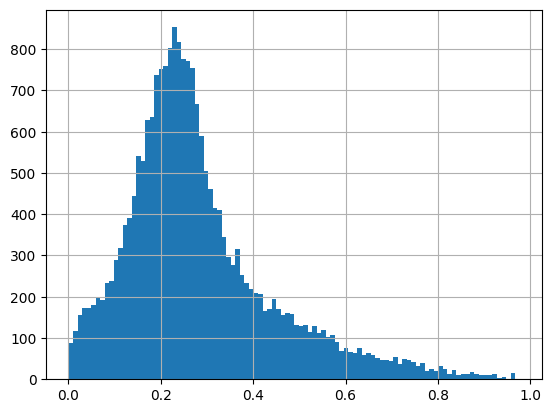

In [64]:
proba = log_reg_tfidf.predict_proba(X_train_tfidf)

pd.Series(proba[:, 2], name='proba_class_1').hist(bins=100)
plt.show()

Розподіл близький до рівномірного з середнім близько 0.25 і довгим хвостом до 1. Виходить що модель дає різну вірогідність але як правило низьку і погано визначає негативні коментарі, напевно зниження порогу не сильно допоможе - хай помилок негативних коментарів стане менше, але в решті класів почне помилятись частіше

що можна додатково спробувати для покращення якості класифікації:
1) збалансувати класи - нейтральних коментарів більше, модель частіше класифікує все як клас 0
2) змінити параметри моделі - збільшити словник, відсіяти рідкісні слова
3) так як цікавить саме визначення негативних коментарів то я б спробував змінити мітки 0 - не негативні коментарі, 1 - негативні і поекспериментувати з цим

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model